In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from sklearn.preprocessing import StandardScaler
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

In [3]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [4]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [5]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [6]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [7]:
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from OUS_D1 and OUS_OS_target in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_ous
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Check if some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Change the form of MAASTRO 
# X
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]

# y_MAASTRO into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

# Check the shape of clincial_test
clinical_test.shape

(99, 16)

In [14]:
clinical_train.head(10)

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
5,57.772603,1,0,0,0,1,1,0.0,0,59.658904,1.0,5.298506,2.846,10.424669,21.106849,1
6,55.791781,0,0,0,0,1,1,0.0,0,56.687671,1.0,8.340148,4.786,31.461777,87.978082,1
7,72.389041,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.301212,7.852,55.919707,62.005479,1
8,53.378082,1,0,1,0,0,1,1.0,0,0.000000,0.0,19.134939,5.898,92.534072,105.073973,0
9,59.076712,0,0,0,1,0,0,0.0,1,41.076712,1.0,17.184191,25.172,317.330329,20.613699,1


# Feature Selection

In [15]:
 
from sklearn.model_selection import StratifiedKFold
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define the columns to be excluded from standardization
excluded_columns = ['female', 
                    'cavum_oris',
                    'oropharynx',
                    'hypopharynx',
                    'larynx',
                    'histgrade_high',
                    'hpv_related',
                    'charlson',
                    'uicc8_III-IV'
                   ]

y_event_os = y['event_OS']

final_sum_results = []  # Store sum results across all iterations

for random_state in range(10): 
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    sum_results = []  # Store sum results for each fold
    
    for train_index, test_index in skf.split(X, y_event_os):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Standardize the included columns
        scaler = StandardScaler()
        X_train_std = scaler.fit_transform(X_train)
        X_test_std = scaler.transform(X_test)

        # Change it to a dataframe
        X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
        X_test_std = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)
        
        final_train_df = pd.concat([X_train_std, y_train], axis=1)
        final_test_df = pd.concat([X_test_std, y_test], axis=1)

        # Fit Cox proportional hazards regression model
        coxph = CoxPHFitter(penalizer=0.0001)
        coxph.fit(final_train_df, duration_col='OS', event_col='event_OS')

        # Get coefficients and associated feature names
        coefficients = coxph.summary['coef']
        feature_names = coxph.summary.index

        # Create a DataFrame to store coefficients and feature names
        coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

        # Take absolute values of coefficients
        coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

        # Sort coefficients by absolute value to identify important features
        sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)
        
        # Sum absolute coefficients for each feature
        sum_abs_coefficient = sorted_coefficients_df.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
        
        # Append to sum_results for this fold
        sum_results.append(sum_abs_coefficient)

    # Concatenate sum_results for all folds
    fold_sum_results = pd.concat(sum_results)
    
    # Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all folds
    final_sum_fold = fold_sum_results.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
    
    # Append to final_sum_results for all random states
    final_sum_results.append(final_sum_fold)

# Concatenate the DataFrames for all random states
final_result = pd.concat(final_sum_results)

# Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all iterations and folds
final_sum = final_result.groupby('Feature')['Abs_Coefficient'].sum().reset_index()

# Rename the column for clarity
final_sum.columns = ['Feature', 'Final_Sum_Abs_Coefficient']

final_sum_sorted = final_sum.sort_values(by='Final_Sum_Abs_Coefficient', ascending=False)

# Display the final result
print(final_sum_sorted)

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 66 right-censored observations>

...

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 66 right-censored observations>

           Feature  Final_Sum_Abs_Coefficient
8      hpv_related                  38.247165
0              MTV                  30.505653
2              TLG                  27.898361
13    uicc8_III-IV                  18.453987
5         charlson                  12.577115
12      pack_years                  10.178529
3              age                  10.038616
9      hypopharynx                   9.704897
11      oropharynx                   9.445131
1          SUVpeak                   8.551332
10          larynx                   6.250346
6           female                   5.900764
7   histgrade_high                   4.221398
4       cavum_oris                   4.020257


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using CoxPH Fitter')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

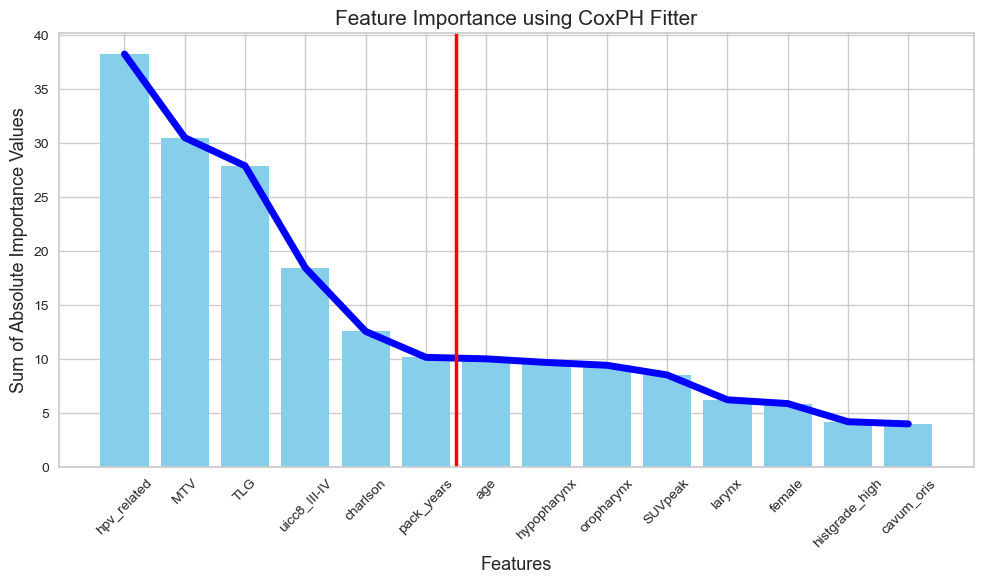

In [21]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(final_sum_sorted['Feature'], 
        final_sum_sorted['Final_Sum_Abs_Coefficient'], 
        color='skyblue')
plt.plot(final_sum_sorted['Feature'], 
         final_sum_sorted['Final_Sum_Abs_Coefficient'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using CoxPH Fitter', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=5.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [22]:
selected_features = final_sum_sorted[0:6]['Feature']
selected_features

8      hpv_related
0              MTV
2              TLG
13    uicc8_III-IV
5         charlson
12      pack_years
Name: Feature, dtype: object

In [23]:
# Selecting features in the DataFrame
X_cfi = X[selected_features]
X_new = X_cfi.copy()

X_MAASTRO_cfi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_cfi.copy()

# Standardization

In [24]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [25]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [26]:
X_new

,hpv_related,MTV,TLG,uicc8_III-IV,charlson,pack_years
0,0.0,7.934,86.228420,0.0,0,0.000000
1,0.0,1.656,7.040100,0.0,1,27.404795
2,0.0,14.502,83.569669,1.0,1,41.019178
3,0.0,2.440,5.567091,0.0,1,37.500000
4,0.0,3.668,16.150550,0.0,1,53.000000
...,...,...,...,...,...,...
134,1.0,3.650,26.280140,0.0,0,0.000000
135,1.0,18.967,101.754834,1.0,0,0.000000
136,1.0,6.370,66.273201,0.0,1,39.498630
137,1.0,12.443,71.832443,1.0,1,71.527397


In [27]:
X_new_std

,hpv_related,MTV,TLG,uicc8_III-IV,charlson,pack_years
0,0.0,-0.296907,-0.179158,0.0,0,-1.101176
1,0.0,-0.763433,-0.587333,0.0,1,0.105775
2,0.0,0.191169,-0.192863,1.0,1,0.705374
3,0.0,-0.705173,-0.594926,0.0,1,0.550384
4,0.0,-0.613919,-0.540373,0.0,1,1.233028
...,...,...,...,...,...,...
134,1.0,-0.615257,-0.488161,0.0,0,-1.101176
135,1.0,0.522969,-0.099128,1.0,0,-1.101176
136,1.0,-0.413130,-0.282017,0.0,1,0.638406
137,1.0,0.038162,-0.253362,1.0,1,2.049005


In [28]:
MAASTRO_new

,hpv_related,MTV,TLG,uicc8_III-IV,charlson,pack_years
0,1,22.841,263.611623,0,1,0
1,0,5.660,36.980700,1,0,20
2,0,7.791,74.636342,1,1,6
3,0,7.908,46.791979,1,1,45
4,1,15.237,107.637514,0,1,59
...,...,...,...,...,...,...
94,0,6.110,144.490782,1,0,55
95,0,7.182,69.214868,1,1,174
96,1,16.483,102.594274,1,1,0
97,1,9.981,103.229492,0,0,0


In [29]:
MAASTRO_new_std

,hpv_related,MTV,TLG,uicc8_III-IV,charlson,pack_years
0,1,0.810851,0.735160,0,1,-1.101176
1,0,-0.465891,-0.433005,1,0,-0.220344
2,0,-0.307534,-0.238909,1,1,-0.836927
3,0,-0.298839,-0.382433,1,1,0.880696
4,1,0.245788,-0.068806,0,1,1.497278
...,...,...,...,...,...,...
94,0,-0.432451,0.121154,1,0,1.321112
95,0,-0.352789,-0.266854,1,1,6.562062
96,1,0.338380,-0.094801,1,1,-1.101176
97,1,-0.144792,-0.091527,0,0,-1.101176


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            print("\n")
            print("y_train time", max(y_train_df["OS"]))
            print("y_test time", max(y_test_df["OS"]))

            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])


            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])  
                print("lower", lower)
                print("upper", upper)
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:46:34,529] A new study created in memory with name: no-name-dd2ca939-dba9-4866-bf17-c5d4f6e23725


  0%|          | 0/1 [00:00<?, ?it/s]



y_train time 111.8465753
y_test time 114.3123288
Fold 1 C-index: 0.775330396475771


y_train time 114.3123288
y_test time 111.8465753
Fold 2 C-index: 0.6752136752136753


y_train time 114.3123288
y_test time 102.0821918
Fold 3 C-index: 0.853448275862069


y_train time 114.3123288
y_test time 84.13150685
Fold 4 C-index: 0.7569721115537849


y_train time 114.3123288
y_test time 84.0
Fold 5 C-index: 0.6810810810810811
[I 2024-04-13 23:46:35,878] Trial 0 finished with value: 0.7484091080372762 and parameters: {}. Best is trial 0 with value: 0.7484091080372762.


[I 2024-04-13 23:46:35,908] A new study created in memory with name: no-name-40770a69-0bcd-4650-a960-5c29ef8aff83




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7484091080372762], datetime_start=datetime.datetime(2024, 4, 13, 23, 46, 34, 659701), datetime_complete=datetime.datetime(2024, 4, 13, 23, 46, 35, 875128), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7484091080372762


  0%|          | 0/1 [00:00<?, ?it/s]



y_train time 111.8465753
y_test time 114.3123288
lower 16.200000000000003
upper 90.3
Fold 1 IBS: 0.17811851327071349


y_train time 114.3123288
y_test time 111.8465753
lower 12.3
upper 73.5
Fold 2 IBS: 0.1903078458628569


y_train time 114.3123288
y_test time 102.0821918
lower 7.4
upper 83.6
Fold 3 IBS: 0.13567215879775504


y_train time 114.3123288
y_test time 84.13150685
lower 12.100000000000001
upper 78.3
Fold 4 IBS: 0.1681608808952863


y_train time 114.3123288
y_test time 84.0
lower 4.6
upper 73.4
Fold 5 IBS: 0.2067357667909638
[I 2024-04-13 23:46:36,878] Trial 0 finished with value: 0.1757990331235151 and parameters: {}. Best is trial 0 with value: 0.1757990331235151.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.1757990331235151], datetime_start=datetime.datetime(2024, 4, 13, 23, 46, 35, 977225), datetime_complete=datetime.datetime(2024, 4, 13, 23, 46, 36, 877900), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distrib

In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.748
train_ibs:  0.176


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.606
IBS score: 0.277


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:46:37,358] A new study created in memory with name: no-name-2ae5b6c8-4494-4588-a90e-d30ee9464b59


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6168831168831169
Fold 2 C-index: 0.6361607142857143
Fold 3 C-index: 0.7377450980392157
Fold 4 C-index: 0.740506329113924


[I 2024-04-13 23:46:37,794] A new study created in memory with name: no-name-34b70e90-2827-4210-af23-fdc0e39267e8


Fold 5 C-index: 0.5633802816901409
[I 2024-04-13 23:46:37,784] Trial 0 finished with value: 0.6589351080024224 and parameters: {}. Best is trial 0 with value: 0.6589351080024224.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6589351080024224], datetime_start=datetime.datetime(2024, 4, 13, 23, 46, 37, 481720), datetime_complete=datetime.datetime(2024, 4, 13, 23, 46, 37, 784567), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6589351080024224


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765174498557
Fold 2 IBS: 0.22157791108309957
Fold 3 IBS: 0.2045359409148848
Fold 4 IBS: 0.2247380350215763
Fold 5 IBS: 0.21812431423859643
[I 2024-04-13 23:46:38,414] Trial 0 finished with value: 0.21659054374160255 and parameters: {}. Best is trial 0 with value: 0.21659054374160255.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054374160255], datetime_start=datetime.datetime(2024, 4, 13, 23, 46, 37, 829174), datetime_complete=datetime.datetime(2024, 4, 13, 23, 46, 38, 414393), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054374160255


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.659
train_ibs:  0.217


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.491


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            print(max(y_train_df["OS"]), max(y_test_df["OS"]))

            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                print("lower", lower)
                print("upper", upper)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:46:39,057] A new study created in memory with name: no-name-c4c84576-4914-451e-8ba9-cc8bec164664


  0%|          | 0/1 [00:00<?, ?it/s]

114.3123288 105.0739726
Fold 1 C-index: 0.7229437229437229
114.3123288 101.260274
Fold 2 C-index: 0.8169642857142857
114.3123288 91.03561644
Fold 3 C-index: 0.8284313725490197
114.3123288 87.97808219
Fold 4 C-index: 0.8185654008438819
105.0739726 114.3123288


[I 2024-04-13 23:46:40,022] A new study created in memory with name: no-name-bd9ece2e-d87c-487f-9ff7-89b3e17dd229


Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:46:39,988] Trial 0 finished with value: 0.7632025526543135 and parameters: {}. Best is trial 0 with value: 0.7632025526543135.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7632025526543135], datetime_start=datetime.datetime(2024, 4, 13, 23, 46, 39, 96504), datetime_complete=datetime.datetime(2024, 4, 13, 23, 46, 39, 987614), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7632025526543135


  0%|          | 0/1 [00:00<?, ?it/s]

114.3123288 105.0739726
lower 13.0
upper 75.60000000000001
Fold 1 IBS: 0.18108028520646072
114.3123288 101.260274
lower 6.0
upper 77.6
Fold 2 IBS: 0.1683932855425463
114.3123288 91.03561644
lower 10.200000000000001
upper 76.9
Fold 3 IBS: 0.1442401419724791
114.3123288 87.97808219
lower 19.4
upper 74.0
Fold 4 IBS: 0.14016895470834714
105.0739726 114.3123288
lower 5.4
upper 94.80000000000003
Fold 5 IBS: 0.2530250512679799
[I 2024-04-13 23:46:41,198] Trial 0 finished with value: 0.17738154373956264 and parameters: {}. Best is trial 0 with value: 0.17738154373956264.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.17738154373956264], datetime_start=datetime.datetime(2024, 4, 13, 23, 46, 40, 82845), datetime_complete=datetime.datetime(2024, 4, 13, 23, 46, 41, 198509), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.17738154373956264


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.763
train_ibs:  0.177


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.604


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.275


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:46:42,387] A new study created in memory with name: no-name-309aedd3-7fb0-4d07-a0e9-33dc743993af


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7229437229437229
Fold 2 C-index: 0.8214285714285714
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:46:43,577] Trial 0 finished with value: 0.7640954097971706 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7640954097971706.
Fold 1 C-index: 0.7229437229437229
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:46:44,728] Trial 1 finished with value: 0.7649882669400278 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.7649882669400278.
Fold 1 C-index: 0.7229437229437229
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:46:45,965] Trial 2 finished with value: 0.765927234076178 and parameters: {'l1_ratio': 0.22692876841884668}. 

Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:47:10,731] Trial 24 finished with value: 0.7649882669400278 and parameters: {'l1_ratio': 0.34357967546552637}. Best is trial 2 with value: 0.765927234076178.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:47:11,780] Trial 25 finished with value: 0.7650614332103772 and parameters: {'l1_ratio': 0.20008685885608116}. Best is trial 2 with value: 0.765927234076178.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:47:12,793] Trial 26 finished with value: 0.7650614332103772 and parameters: {'l1_ratio': 0.12316751626230191}. Best is trial 2 with value: 0.76

Fold 1 C-index: 0.7229437229437229
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:47:38,301] Trial 48 finished with value: 0.7649882669400278 and parameters: {'l1_ratio': 0.2571953178969567}. Best is trial 2 with value: 0.765927234076178.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:47:39,337] Trial 49 finished with value: 0.7650614332103772 and parameters: {'l1_ratio': 0.15405453795864016}. Best is trial 2 with value: 0.765927234076178.
Fold 1 C-index: 0.7229437229437229
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:47:40,390] Trial 50 finished with value: 0.7649882669400278 and parameters: {'l1_ratio': 0.21709008936153046}

...

Fold 1 IBS: 0.18113352408265854
Fold 2 IBS: 0.1679638772643223
Fold 3 IBS: 0.1441117695261426
Fold 4 IBS: 0.14008932212043138
Fold 5 IBS: 0.25294372408642646
[I 2024-04-13 23:48:49,064] Trial 0 finished with value: 0.17724844341599627 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.17724844341599627.
Fold 1 IBS: 0.18123294925260686
Fold 2 IBS: 0.1672906436471852
Fold 3 IBS: 0.14390034588242376
Fold 4 IBS: 0.1399732930754434
Fold 5 IBS: 0.25286188305454416
[I 2024-04-13 23:48:50,706] Trial 1 finished with value: 0.17705182298244065 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.17705182298244065.
Fold 1 IBS: 0.18126033421545087
Fold 2 IBS: 0.16717797817254437
Fold 3 IBS: 0.14385778268993588
Fold 4 IBS: 0.13995002171398643
Fold 5 IBS: 0.2528242272089536
[I 2024-04-13 23:48:52,784] Trial 2 finished with value: 0.17701406880017423 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.17701406880017

Fold 1 IBS: 0.18122713150857025
Fold 2 IBS: 0.16739503651097995
Fold 3 IBS: 0.1439258004496043
Fold 4 IBS: 0.13998866384946562
Fold 5 IBS: 0.25285922992902077
[I 2024-04-13 23:49:22,487] Trial 25 finished with value: 0.17707917244952817 and parameters: {'l1_ratio': 0.34372750160857113}. Best is trial 18 with value: 0.1769211566753989.
Fold 1 IBS: 0.1812972010748347
Fold 2 IBS: 0.16690670305428076
Fold 3 IBS: 0.1437751122701435
Fold 4 IBS: 0.13990363844133016
Fold 5 IBS: 0.25277790500086106
[I 2024-04-13 23:49:23,906] Trial 26 finished with value: 0.17693211196829003 and parameters: {'l1_ratio': 0.08609654332816143}. Best is trial 18 with value: 0.1769211566753989.
Fold 1 IBS: 0.18125748052504534
Fold 2 IBS: 0.16710002696776607
Fold 3 IBS: 0.14384730778711768
Fold 4 IBS: 0.13994282767016714
Fold 5 IBS: 0.25282793037373663
[I 2024-04-13 23:49:25,164] Trial 27 finished with value: 0.17699511466476658 and parameters: {'l1_ratio': 0.19159201191781092}. Best is trial 18 with value: 0.1769211

Fold 5 IBS: 0.2527708479102207
[I 2024-04-13 23:49:56,827] Trial 49 finished with value: 0.21599601839838303 and parameters: {'l1_ratio': 0.028025656624991277}. Best is trial 28 with value: 0.17692023707013949.
Fold 1 IBS: 0.18128182790302852
Fold 2 IBS: 0.16689014271296754
Fold 3 IBS: 0.1437899668355495
Fold 4 IBS: 0.1399106568046745
Fold 5 IBS: 0.2528002313725994
[I 2024-04-13 23:49:58,241] Trial 50 finished with value: 0.1769345651257639 and parameters: {'l1_ratio': 0.08888770157152942}. Best is trial 28 with value: 0.17692023707013949.
Fold 1 IBS: 0.18127655139536394
Fold 2 IBS: 0.1668959705748857
Fold 3 IBS: 0.14379510475877377
Fold 4 IBS: 0.13991309415367595
Fold 5 IBS: 0.2528132185613731
[I 2024-04-13 23:49:59,934] Trial 51 finished with value: 0.1769387878888145 and parameters: {'l1_ratio': 0.08988811687672167}. Best is trial 28 with value: 0.17692023707013949.
Fold 1 IBS: 0.1813062480755811
Fold 2 IBS: 0.16698597606509621
Fold 3 IBS: 0.14382206762909383
Fold 4 IBS: 0.139910409

Fold 1 IBS: 0.18131315983670818
Fold 2 IBS: 0.16692015018618545
Fold 3 IBS: 0.1438051451037033
Fold 4 IBS: 0.13989971694991424
Fold 5 IBS: 0.2528282431132788
[I 2024-04-13 23:50:40,144] Trial 74 finished with value: 0.176953283037958 and parameters: {'l1_ratio': 0.09995088562162313}. Best is trial 63 with value: 0.17691970359917591.
Fold 1 IBS: 0.18118725486209292
Fold 2 IBS: 0.16771183516096091
Fold 3 IBS: 0.14401958427673545
Fold 4 IBS: 0.14004216966842617
Fold 5 IBS: 0.2529309004873422
[I 2024-04-13 23:50:41,301] Trial 75 finished with value: 0.17717834889111153 and parameters: {'l1_ratio': 0.523110210901512}. Best is trial 63 with value: 0.17691970359917591.
Fold 1 IBS: 0.18130731452288268
Fold 2 IBS: 0.16684971968670864
Fold 3 IBS: 0.14375578145814039
Fold 4 IBS: 0.2214789958539272
Fold 5 IBS: 0.252762443394746
[I 2024-04-13 23:50:42,564] Trial 76 finished with value: 0.19323085098328097 and parameters: {'l1_ratio': 0.05857998294397039}. Best is trial 63 with value: 0.176919703599

Fold 5 IBS: 0.25281889298911503
[I 2024-04-13 23:51:14,344] Trial 98 finished with value: 0.17696792395018082 and parameters: {'l1_ratio': 0.1438224142404198}. Best is trial 63 with value: 0.17691970359917591.
Fold 1 IBS: 0.1813085006763898
Fold 2 IBS: 0.16685859138562992
Fold 3 IBS: 0.1437566586821097
Fold 4 IBS: 0.13989379655589976
Fold 5 IBS: 0.25285065039484084
[I 2024-04-13 23:51:16,858] Trial 99 finished with value: 0.176933639538974 and parameters: {'l1_ratio': 0.06403344862565462}. Best is trial 63 with value: 0.17691970359917591.


* Best trial for IBS: 
 FrozenTrial(number=63, state=TrialState.COMPLETE, values=[0.17691970359917591], datetime_start=datetime.datetime(2024, 4, 13, 23, 50, 18, 727212), datetime_complete=datetime.datetime(2024, 4, 13, 23, 50, 21, 98337), params={'l1_ratio': 0.06662138318765341}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=63, value=None)

In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.766
train_ibs:  0.177


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.22692876841884668)

test_cindex : 0.603


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.06662138318765341)

test_ibs:  0.276


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:51:18,533] A new study created in memory with name: no-name-7c96aecd-5675-4d61-8b8a-38e4db8e4054


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7359307359307359
Fold 2 C-index: 0.71875
Fold 3 C-index: 0.8014705882352942
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6408450704225352
[I 2024-04-13 23:51:38,494] Trial 0 finished with value: 0.7473317683691898 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7473317683691898.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.8565400843881856
Fold 5 C-index: 0.6596244131455399
[I 2024-04-13 23:51:49,858] Trial 1 finished with value: 0.7554292325854312 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_featur

Fold 5 C-index: 0.7065727699530516
[I 2024-04-13 23:53:47,700] Trial 15 finished with value: 0.7867424863833603 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 15, 'min_samples_leaf': 15, 'max_depth': 7, 'n_estimators': 197, 'oob_score': True, 'max_samples': 0.9835664616143871, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.0921839163034627, 'warm_start': True}. Best is trial 14 with value: 0.7975820314835605.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.8459821428571429
Fold 3 C-index: 0.8529411764705882
Fold 4 C-index: 0.869198312236287
Fold 5 C-index: 0.7018779342723005
[I 2024-04-13 23:53:50,130] Trial 16 finished with value: 0.7994544586218092 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 2, 'n_estimators': 62, 'oob_score': True, 'max_samples': 0.9622193970781673, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07748782870655765, 'warm_start': True}. Best is trial 16 with value: 0.799454458621809

Fold 1 C-index: 0.7142857142857143
Fold 2 C-index: 0.8549107142857143
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8755274261603375
Fold 5 C-index: 0.7018779342723005
[I 2024-04-13 23:54:44,495] Trial 30 finished with value: 0.7901046715263036 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 16, 'n_estimators': 87, 'oob_score': True, 'max_samples': 0.9401961816679979, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.20001380215328324, 'warm_start': True}. Best is trial 22 with value: 0.8007542550481027.
Fold 1 C-index: 0.696969696969697
Fold 2 C-index: 0.8482142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8734177215189873
Fold 5 C-index: 0.7347417840375586
[I 2024-04-13 23:54:49,616] Trial 31 finished with value: 0.7953745800010469 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 11, 'max_depth': 18, 'n_estimators': 128, 'oob_score': True, 'max_samples': 0.882442471995794

...

Fold 1 IBS: 0.17720278388184146
Fold 2 IBS: 0.19817953994605847
Fold 3 IBS: 0.15666653531513672
Fold 4 IBS: 0.1500342261161219
Fold 5 IBS: 0.2296927349436163
[I 2024-04-14 00:08:32,491] Trial 32 finished with value: 0.182355164040555 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 11, 'max_depth': 5, 'n_estimators': 397, 'oob_score': False, 'max_samples': 0.9502203520505428, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.021107187603794535}. Best is trial 5 with value: 0.1818235508772977.
Fold 1 IBS: 0.17600259211909575
Fold 2 IBS: 0.1983594143255591
Fold 3 IBS: 0.1576446729763265
Fold 4 IBS: 0.15362714597065677
Fold 5 IBS: 0.22836456912147912
[I 2024-04-14 00:08:49,019] Trial 33 finished with value: 0.18279967890262344 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 15, 'min_samples_leaf': 13, 'max_depth': 7, 'n_estimators': 391, 'oob_score': False, 'max_samples': 0.9873132182388158, 'max_features': 'auto', 'min_weight_fraction_le

Fold 1 IBS: 0.21403800727892303
Fold 2 IBS: 0.2214833018680735
Fold 3 IBS: 0.20477111879039447
Fold 4 IBS: 0.22466421572670492
Fold 5 IBS: 0.21869472997850736
[I 2024-04-14 00:32:34,399] Trial 48 finished with value: 0.21673027472852063 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 20, 'n_estimators': 219, 'oob_score': False, 'max_samples': 0.626402586079744, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 5 with value: 0.1818235508772977.
Fold 1 IBS: 0.1800174545856961
Fold 2 IBS: 0.1960943270444747
Fold 3 IBS: 0.16032714180715094
Fold 4 IBS: 0.15867982081440885
Fold 5 IBS: 0.22782586625748233
[I 2024-04-14 00:32:48,674] Trial 49 finished with value: 0.18458892210184258 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 15, 'min_samples_leaf': 11, 'max_depth': 15, 'n_estimators': 304, 'oob_score': False, 'max_samples': 0.573574934951013, 'max_features': 'auto', 'min_weight_fraction_le

Fold 1 IBS: 0.1779448650883299
Fold 2 IBS: 0.2006018185344419
Fold 3 IBS: 0.15513910082907756
Fold 4 IBS: 0.14670546759484
Fold 5 IBS: 0.22994789612520788
[I 2024-04-14 00:36:39,053] Trial 64 finished with value: 0.18206782963437945 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 14, 'min_samples_leaf': 9, 'max_depth': 3, 'n_estimators': 364, 'oob_score': False, 'max_samples': 0.9069243379274685, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.08425907433944713}. Best is trial 5 with value: 0.1818235508772977.
Fold 1 IBS: 0.1819539240672461
Fold 2 IBS: 0.20327909879815237
Fold 3 IBS: 0.1539145055728263
Fold 4 IBS: 0.1450092113514973
Fold 5 IBS: 0.2302849570350781
[I 2024-04-14 00:36:45,745] Trial 65 finished with value: 0.18288833936496005 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 14, 'min_samples_leaf': 7, 'max_depth': 3, 'n_estimators': 121, 'oob_score': False, 'max_samples': 0.9023457510701132, 'max_features': 'auto', 'min_weight_fraction_leaf': 0

Fold 1 IBS: 0.1796440850757974
Fold 2 IBS: 0.1980287285000558
Fold 3 IBS: 0.16188972786608022
Fold 4 IBS: 0.16215158278121658
Fold 5 IBS: 0.22511338473447343
[I 2024-04-14 00:40:50,028] Trial 80 finished with value: 0.18536550179152467 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 3, 'n_estimators': 358, 'oob_score': True, 'max_samples': 0.7228486046150282, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.16983888675777759}. Best is trial 70 with value: 0.18073566467616312.
Fold 1 IBS: 0.1759972031430692
Fold 2 IBS: 0.19934050381156884
Fold 3 IBS: 0.15748570311572135
Fold 4 IBS: 0.14642106271489444
Fold 5 IBS: 0.22511719384422035
[I 2024-04-14 00:41:10,471] Trial 81 finished with value: 0.18087233332589484 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 2, 'n_estimators': 392, 'oob_score': True, 'max_samples': 0.918458767461019, 'max_features': 'log2', 'min_weight_fraction_lea

Fold 5 IBS: 0.2172423066880412
[I 2024-04-14 00:45:20,943] Trial 95 finished with value: 0.18606281076304074 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 1, 'n_estimators': 447, 'oob_score': True, 'max_samples': 0.7647422369683312, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.04582861412162082}. Best is trial 94 with value: 0.18038880678221694.
Fold 1 IBS: 0.17607571840234232
Fold 2 IBS: 0.2010229869637368
Fold 3 IBS: 0.15723271196316843
Fold 4 IBS: 0.14417053432218166
Fold 5 IBS: 0.2244954618415223
[I 2024-04-14 00:45:38,567] Trial 96 finished with value: 0.1805994826985903 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 2, 'n_estimators': 437, 'oob_score': True, 'max_samples': 0.8090469335560372, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.06782895951191581}. Best is trial 94 with value: 0.18038880678221694.
Fold 1 IBS: 0.17878300018143867
Fold 2 IBS: 0.208791

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.855
train_ibs:  0.18


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=9, max_features=None, max_leaf_nodes=8,
                     max_samples=0.7729862417719584, min_samples_leaf=2,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.02844949378963749,
                     n_estimators=338, random_state=123, warm_start=True)

test_cindex:  0.666


RandomSurvivalForest(max_depth=2, max_features='log2', max_leaf_nodes=19,
                     max_samples=0.7942217997295188, min_samples_leaf=2,
                     min_samples_split=15,
                     min_weight_fraction_leaf=0.045100977319859445,
                     n_estimators=437, oob_score=True, random_state=123)

test_ibs:  0.208


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:46:44,372] A new study created in memory with name: no-name-fb5f6626-e949-4dd2-af9d-767d36b90a58


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.84375
Fold 3 C-index: 0.8627450980392157
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6807511737089202
[I 2024-04-14 00:46:47,292] Trial 0 finished with value: 0.7934775298715735 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7934775298715735.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:46:54,926] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}. Best is 

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:48:16,640] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 7, 'max_depth': 3, 'n_estimators': 497, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.10043506002193597, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 0 with value: 0.7934775298715735.
Fold 1 C-index: 0.7619047619047619
Fold 2 C-index: 0.8214285714285714
Fold 3 C-index: 0.8308823529411765
Fold 4 C-index: 0.8291139240506329
Fold 5 C-index: 0.6549295774647887
[I 2024-04-14 00:48:21,254] Trial 17 finished with value: 0.7796518375579863 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 16, 'n_estimators': 381, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.680642613858846, 'min_weight_fraction_leaf': 0.19239050103117

Fold 1 C-index: 0.7510822510822511
Fold 2 C-index: 0.8526785714285714
Fold 3 C-index: 0.8578431372549019
Fold 4 C-index: 0.8354430379746836
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:48:53,504] Trial 31 finished with value: 0.7918037657452647 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 238, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.9417534534350702, 'min_weight_fraction_leaf': 0.03857261092680618}. Best is trial 28 with value: 0.7984122749652544.
Fold 1 C-index: 0.7359307359307359
Fold 2 C-index: 0.8571428571428571
Fold 3 C-index: 0.8627450980392157
Fold 4 C-index: 0.8270042194092827
Fold 5 C-index: 0.676056338028169
[I 2024-04-14 00:48:55,066] Trial 32 finished with value: 0.7917758497100521 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 140, 'oob_score': False, 'warm_start': True, 'max_featur

...

Fold 1 IBS: 0.17420925653790728
Fold 2 IBS: 0.19589814645292894
Fold 3 IBS: 0.1691061482646708
Fold 4 IBS: 0.17312070476809152
Fold 5 IBS: 0.22211123070005245
[I 2024-04-14 01:00:12,196] Trial 30 finished with value: 0.1868890973447302 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 2, 'max_depth': 8, 'n_estimators': 328, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.23846812660748434}. Best is trial 19 with value: 0.18080136943306072.
Fold 1 IBS: 0.169332532583171
Fold 2 IBS: 0.1901414747247537
Fold 3 IBS: 0.1580833841932921
Fold 4 IBS: 0.15967709092434465
Fold 5 IBS: 0.22778437577460006
[I 2024-04-14 01:00:18,868] Trial 31 finished with value: 0.1810037716400323 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 6, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 217, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.59505

Fold 1 IBS: 0.17120184206970895
Fold 2 IBS: 0.19463313026289608
Fold 3 IBS: 0.16677497883413742
Fold 4 IBS: 0.16893706229268562
Fold 5 IBS: 0.2234238243942854
[I 2024-04-14 01:01:58,317] Trial 45 finished with value: 0.18499416757074272 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 8, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 447, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.2769725054234149, 'min_weight_fraction_leaf': 0.018364120014137026}. Best is trial 41 with value: 0.18027628360563291.
Fold 1 IBS: 0.17226068156733812
Fold 2 IBS: 0.19496460423977766
Fold 3 IBS: 0.1668947242480988
Fold 4 IBS: 0.1693186879959306
Fold 5 IBS: 0.22548749349359926
[I 2024-04-14 01:02:10,807] Trial 46 finished with value: 0.18578523830894889 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 393, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples':

Fold 1 IBS: 0.17081391925068787
Fold 2 IBS: 0.1925028333313774
Fold 3 IBS: 0.16073464353915767
Fold 4 IBS: 0.1628210075881909
Fold 5 IBS: 0.22680791404433995
[I 2024-04-14 01:03:40,812] Trial 60 finished with value: 0.18273606355075075 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 14, 'min_samples_leaf': 9, 'max_depth': 3, 'n_estimators': 241, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.7202840957637079, 'min_weight_fraction_leaf': 0.03413805181555945}. Best is trial 41 with value: 0.18027628360563291.
Fold 1 IBS: 0.16926743292571358
Fold 2 IBS: 0.19299172162688055
Fold 3 IBS: 0.15832449117950878
Fold 4 IBS: 0.1577759542076824
Fold 5 IBS: 0.2290169824369651
[I 2024-04-14 01:03:48,858] Trial 61 finished with value: 0.1814753164753501 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 11, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 288, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.

Fold 1 IBS: 0.16895250600284004
Fold 2 IBS: 0.19273512528967437
Fold 3 IBS: 0.15674031870444
Fold 4 IBS: 0.15465169605447746
Fold 5 IBS: 0.22835174992541069
[I 2024-04-14 01:05:12,815] Trial 75 finished with value: 0.1802862791953685 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 10, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 150, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8635228393990211, 'min_weight_fraction_leaf': 0.018700589718225774}. Best is trial 72 with value: 0.18017573025988107.
Fold 1 IBS: 0.16961769290227408
Fold 2 IBS: 0.1957661970064487
Fold 3 IBS: 0.15684457495871731
Fold 4 IBS: 0.15467211583289547
Fold 5 IBS: 0.22778758956407522
[I 2024-04-14 01:05:18,086] Trial 76 finished with value: 0.18093763405288216 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 10, 'min_samples_leaf': 6, 'max_depth': 8, 'n_estimators': 162, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.

Fold 1 IBS: 0.16950685836239654
Fold 2 IBS: 0.19517075062825745
Fold 3 IBS: 0.15793218794328956
Fold 4 IBS: 0.15669730201946813
Fold 5 IBS: 0.22807998717102346
[I 2024-04-14 01:06:15,826] Trial 90 finished with value: 0.18147741722488706 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 2, 'max_depth': 10, 'n_estimators': 170, 'oob_score': True, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.9717034739045768, 'min_weight_fraction_leaf': 0.08174992537387354}. Best is trial 86 with value: 0.17970422002626374.
Fold 1 IBS: 0.16817626292441637
Fold 2 IBS: 0.19229640752899757
Fold 3 IBS: 0.15471588196574004
Fold 4 IBS: 0.1531997100088726
Fold 5 IBS: 0.22811127461827668
[I 2024-04-14 01:06:21,886] Trial 91 finished with value: 0.17929990740926066 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 9, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 152, 'oob_score': True, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.809
train_ibs:  0.179


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=5, max_features=0.1, max_leaf_nodes=20,
                   max_samples=0.696872765602893, min_samples_leaf=2,
                   min_weight_fraction_leaf=0.024759034183909425,
                   n_estimators=323, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.643


ExtraSurvivalTrees(max_depth=12, max_features='auto', max_leaf_nodes=10,
                   max_samples=0.9341473233163816, min_samples_split=16,
                   min_weight_fraction_leaf=0.029682652080537567,
                   n_estimators=204, oob_score=True, random_state=123,
                   warm_start=True)

IBS: 0.219


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 01:07:23,715] A new study created in memory with name: no-name-749d7e5c-5fac-4942-aaa3-b554d1740ac0


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:08:15,850] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:08:45,683] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:23:14,313] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7442734332505105.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:25:01,495] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:43:07,297] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7442734332505105.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 01:45:07,978] Trial 26 finished with value: 0.5790978827510518 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_es

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 05:02:55,896] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.918589848048704, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.1366452847323028, 'n_estimators': 388, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.18967222528443176, 'max_features': 'auto', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 18}. Best is trial 22 with value: 0.21565853943071014.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:05:08,064] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.7513175598857118, 'learning_rate': 0.0985092209

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:24:14,719] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.05359198006915804, 'dropout_rate': 0.650983074619535, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.713342732410399, 'min_weight_fraction_leaf': 0.037327349410482574, 'max_features': 0.1, 'min_impurity_decrease': 4.636270239719423e-07, 'validation_fraction': 0.7909756969364712, 'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 18, 'max_depth': 19}. Best is trial 22 with value: 0.21565853943071014.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:25:38,984] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8945047973351204, 'learning_rate': 0.03028968218872250

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 05:42:27,684] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.009617814274368723, 'dropout_rate': 0.23464360454432553, 'n_estimators': 449, 'criterion': 'squared_error', 'ccp_alpha': 0.5872217111247551, 'min_weight_fraction_leaf': 0.12767889602965304, 'max_features': 1, 'min_impurity_decrease': 1.4509408420175117e-05, 'validation_fraction': 0.9291496186906082, 'min_samples_split': 8, 'max_leaf_nodes': 6, 'min_samples_leaf': 20, 'max_depth': 5}. Best is trial 72 with value: 0.21557077524496698.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609557
[I 2024-04-14 05:44:59,922] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9412481314247185, 'learning_rate': 0.01401320577538

Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 06:08:29,413] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7762725560789899, 'learning_rate': 0.002840775604598951, 'dropout_rate': 0.17679523101040587, 'n_estimators': 439, 'criterion': 'squared_error', 'ccp_alpha': 1.3457840140168202, 'min_weight_fraction_leaf': 0.27772784044341225, 'max_features': 'auto', 'min_impurity_decrease': 7.146310105770256e-07, 'validation_fraction': 0.9468846139081949, 'min_samples_split': 20, 'max_leaf_nodes': 20, 'min_samples_leaf': 17, 'max_depth': 1}. Best is trial 72 with value: 0.21557077524496698.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 06:10:18,694] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9768418957436514

Fold 2 IBS: 0.22114687366142755
Fold 3 IBS: 0.20309776624557802
Fold 4 IBS: 0.2230272521428382
Fold 5 IBS: 0.21794805458203664
[I 2024-04-14 06:24:24,776] Trial 99 finished with value: 0.21557589428220184 and parameters: {'subsample': 0.8345890885513999, 'learning_rate': 0.01638445996831051, 'dropout_rate': 0.3381140897621473, 'n_estimators': 350, 'criterion': 'squared_error', 'ccp_alpha': 0.004422201299274769, 'min_weight_fraction_leaf': 0.25005462596245476, 'max_features': 'auto', 'min_impurity_decrease': 2.469611712550214e-07, 'validation_fraction': 0.9508263292671201, 'min_samples_split': 10, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 92 with value: 0.21382539298851316.


* Best trial for IBS: 
 FrozenTrial(number=92, state=TrialState.COMPLETE, values=[0.21382539298851316], datetime_start=datetime.datetime(2024, 4, 14, 6, 14, 17, 488059), datetime_complete=datetime.datetime(2024, 4, 14, 6, 15, 17, 453894), params={'subsample': 0.5328328014893517, '

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.745
train_ibs:  0.214


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03063070291051248,
                                 criterion='squared_error',
                                 dropout_rate=0.2576884847115747,
                                 learning_rate=0.007359366951045268,
                                 max_depth=16, max_features=1,
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=1.3903906488794697e-07,
                                 min_samples_leaf=14, min_samples_split=20,
                                 min_weight_fraction_leaf=0.38180626899357545,
                                 n_estimators=96, random_state=123,
                                 subsample=0.8938290428827321,
                                 validation_fraction=0.9577535215137098)

C-index score: 0.586


GradientBoostingSurvivalAnalysis(ccp_alpha=0.04676515809970792,
                                 criterion='squared_error',
                                 dropout_rate=0.11858709113908081,
                                 learning_rate=0.015779816215187453,
                                 max_depth=2, max_features='auto',
                                 max_leaf_nodes=19,
                                 min_impurity_decrease=2.511788162760691e-07,
                                 min_samples_leaf=17, min_samples_split=11,
                                 min_weight_fraction_leaf=0.35197101094495303,
                                 n_estimators=261, random_state=123,
                                 subsample=0.5328328014893517,
                                 validation_fraction=0.691850183800161)

IBS: 0.219


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis


#### Train

In [73]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:24:39,847] A new study created in memory with name: no-name-7e87ed4b-0737-486a-9c73-b38d107209c5


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7549019607843137
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5938967136150235
[I 2024-04-14 06:24:42,189] Trial 0 finished with value: 0.7006175901048113 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.7006175901048113.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5985915492957746
[I 2024-04-14 06:25:03,719] Trial 1 finished with value: 0.699595772927236 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.7006175901048113.
Fold 1 C-index: 0.7445887445887446
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7671568627450981
Fold 4 C-index: 0.78902953586497

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7598039215686274
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5985915492957746
[I 2024-04-14 06:27:32,418] Trial 19 finished with value: 0.701644092254967 and parameters: {'subsample': 0.6457256401960624, 'dropout_rate': 0.7254192287154788, 'n_estimators': 131, 'learning_rate': 0.08697733590757546}. Best is trial 15 with value: 0.7174862037474513.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5845070422535211
[I 2024-04-14 06:27:42,919] Trial 20 finished with value: 0.7036416166168245 and parameters: {'subsample': 0.8986193768259231, 'dropout_rate': 0.18732898522307728, 'n_estimators': 317, 'learning_rate': 0.06551866052750378}. Best is trial 15 with value: 0.7174862037474513.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6473214285714286
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5892018779342723
[I 2024-04-14 06:30:40,898] Trial 38 finished with value: 0.7046681187669803 and parameters: {'subsample': 0.8078746525666788, 'dropout_rate': 0.15266630898677364, 'n_estimators': 180, 'learning_rate': 0.06028724397863987}. Best is trial 15 with value: 0.7174862037474513.
Fold 1 C-index: 0.7445887445887446
Fold 2 C-index: 0.6383928571428571
Fold 3 C-index: 0.7573529411764706
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5821596244131455
[I 2024-04-14 06:30:51,226] Trial 39 finished with value: 0.7023047406372394 and parameters: {'subsample': 0.4135044908822448, 'dropout_rate': 0.10196882902995949, 'n_estimators': 294, 'learning_rate': 0.01033884503473171}. Best is trial 15 with value: 0.7174862037474513.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7598039215686274
Fold 4 C-ind

...

Fold 3 IBS: 0.1734082854521142
Fold 4 IBS: 0.1931324004236852
Fold 5 IBS: 0.21814307224075255
[I 2024-04-14 06:42:01,958] Trial 19 finished with value: 0.19599386317980236 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9930703343219778, 'n_estimators': 51, 'learning_rate': 0.04096883532946153}. Best is trial 19 with value: 0.19599386317980236.
Fold 1 IBS: 0.19583618113480916
Fold 2 IBS: 0.20460390544410206
Fold 3 IBS: 0.17911339047513355
Fold 4 IBS: 0.2008234467071609
Fold 5 IBS: 0.2209799818656319
[I 2024-04-14 06:42:02,915] Trial 20 finished with value: 0.20027138112536752 and parameters: {'subsample': 0.1435040576337751, 'dropout_rate': 0.7933084651006226, 'n_estimators': 43, 'learning_rate': 0.04127909023805986}. Best is trial 19 with value: 0.19599386317980236.
Fold 1 IBS: 0.1978165282113557
Fold 2 IBS: 0.20464988267844106
Fold 3 IBS: 0.1825159006164142
Fold 4 IBS: 0.2015576595294096
Fold 5 IBS: 0.21745092435145094
[I 2024-04-14 06:42:03,736] Trial 21 finishe

Fold 3 IBS: 0.1636399539225508
Fold 4 IBS: 0.16769282158108997
Fold 5 IBS: 0.2481370192855935
[I 2024-04-14 06:42:47,753] Trial 38 finished with value: 0.19798029212262153 and parameters: {'subsample': 0.1652649791020655, 'dropout_rate': 0.9253459735969143, 'n_estimators': 162, 'learning_rate': 0.026764408197071425}. Best is trial 31 with value: 0.19356116189682954.
Fold 1 IBS: 0.1756535901449129
Fold 2 IBS: 0.260684000432357
Fold 3 IBS: 0.1860329378285459
Fold 4 IBS: 0.15966737522070576
Fold 5 IBS: 0.2731998474424504
[I 2024-04-14 06:42:49,574] Trial 39 finished with value: 0.21104755021379437 and parameters: {'subsample': 0.4386645564776548, 'dropout_rate': 0.5020285928110546, 'n_estimators': 80, 'learning_rate': 0.06892741183938003}. Best is trial 31 with value: 0.19356116189682954.
Fold 1 IBS: 0.19085598432083065
Fold 2 IBS: 0.3485302361770313
Fold 3 IBS: 0.2351037795297697
Fold 4 IBS: 0.15685415014006784
Fold 5 IBS: 0.32653203976537587
[I 2024-04-14 06:43:07,591] Trial 40 finished

Fold 2 IBS: 0.2748885222817686
Fold 3 IBS: 0.18267301314085205
Fold 4 IBS: 0.14463864295629464
Fold 5 IBS: 0.2929685964306931
[I 2024-04-14 06:45:26,099] Trial 57 finished with value: 0.21814402949961922 and parameters: {'subsample': 0.10157668237117877, 'dropout_rate': 0.4673508580212206, 'n_estimators': 299, 'learning_rate': 0.037031664323292204}. Best is trial 31 with value: 0.19356116189682954.
Fold 1 IBS: 0.20913256400722866
Fold 2 IBS: 0.21481856167565722
Fold 3 IBS: 0.19786376592436886
Fold 4 IBS: 0.2183889655550011
Fold 5 IBS: 0.21686755434847663
[I 2024-04-14 06:45:27,723] Trial 58 finished with value: 0.21141428230214648 and parameters: {'subsample': 0.1520821436381236, 'dropout_rate': 0.43298080625556246, 'n_estimators': 85, 'learning_rate': 0.004624515269539288}. Best is trial 31 with value: 0.19356116189682954.
Fold 1 IBS: 0.17839945064610585
Fold 2 IBS: 0.24580740288814
Fold 3 IBS: 0.16277845518615258
Fold 4 IBS: 0.16344108562156298
Fold 5 IBS: 0.25895777797089203
[I 2024

Fold 1 IBS: 0.20619734699266912
Fold 2 IBS: 0.28812425078205633
Fold 3 IBS: 0.20171065793662227
Fold 4 IBS: 0.15186437749884912
Fold 5 IBS: 0.30175402423686465
[I 2024-04-14 06:47:36,533] Trial 76 finished with value: 0.2299301314894123 and parameters: {'subsample': 0.10195198292493993, 'dropout_rate': 0.8157403211471965, 'n_estimators': 363, 'learning_rate': 0.03771337697167211}. Best is trial 31 with value: 0.19356116189682954.
Fold 1 IBS: 0.17991568925509263
Fold 2 IBS: 0.22412160510591403
Fold 3 IBS: 0.16539827067218382
Fold 4 IBS: 0.16861014883863737
Fold 5 IBS: 0.24619228213707817
[I 2024-04-14 06:47:48,324] Trial 77 finished with value: 0.19684759920178121 and parameters: {'subsample': 0.17063595522421857, 'dropout_rate': 0.5340794382591971, 'n_estimators': 427, 'learning_rate': 0.010050363234543506}. Best is trial 31 with value: 0.19356116189682954.
Fold 1 IBS: 0.19188645715440236
Fold 2 IBS: 0.2039941244517319
Fold 3 IBS: 0.17311801510475525
Fold 4 IBS: 0.19097246687143674
Fol

Fold 1 IBS: 0.18420599018326247
Fold 2 IBS: 0.21050740412350352
Fold 3 IBS: 0.16596336856562205
Fold 4 IBS: 0.17799429351987986
Fold 5 IBS: 0.2327060289244772
[I 2024-04-14 06:49:47,367] Trial 95 finished with value: 0.19427541706334903 and parameters: {'subsample': 0.15131182883043204, 'dropout_rate': 0.13067742271478996, 'n_estimators': 290, 'learning_rate': 0.011308912230416085}. Best is trial 31 with value: 0.19356116189682954.
Fold 1 IBS: 0.17621249951951795
Fold 2 IBS: 0.23833878090176913
Fold 3 IBS: 0.16259589157816187
Fold 4 IBS: 0.16082664146548617
Fold 5 IBS: 0.25849386548048897
[I 2024-04-14 06:49:53,561] Trial 96 finished with value: 0.19929353578908482 and parameters: {'subsample': 0.153683476690887, 'dropout_rate': 0.9184732217504012, 'n_estimators': 290, 'learning_rate': 0.01820424580215757}. Best is trial 31 with value: 0.19356116189682954.
Fold 1 IBS: 0.1935728015311324
Fold 2 IBS: 0.205588790709146
Fold 3 IBS: 0.17549721918603386
Fold 4 IBS: 0.19434606186561965
Fold 5

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.717
train_ibs:  0.194


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10006460023230275,
                                              learning_rate=0.08616677729964022,
                                              n_estimators=297,
                                              random_state=123,
                                              subsample=0.8897480564271555)

C-index score: 0.533


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9986305388341156,
                                              learning_rate=0.034656609251772795,
                                              n_estimators=111,
                                              random_state=123,
                                              subsample=0.10837826831686778)

IBS: 0.273


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.855,1.0
ExtraSurvivalTrees,0.809,2.0
CoxElastic,0.766,3.0
CoxLasso,0.763,4.0
CoxPH,0.748,5.0
GradientBoosting,0.745,6.0
ComponentwiseGradientBoosting,0.717,7.0
CoxRidge,0.659,8.0


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
CoxPH,0.176,1.0
CoxLasso,0.177,2.5
CoxElastic,0.177,2.5
ExtraSurvivalTrees,0.179,4.0
Randomsurvivalforest,0.180,5.0
ComponentwiseGradientBoosting,0.194,6.0
GradientBoosting,0.214,7.0
CoxRidge,0.217,8.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.666,1.0
ExtraSurvivalTrees,0.643,2.0
CoxPH,0.606,3.0
CoxLasso,0.604,4.0
CoxElastic,0.603,5.0
GradientBoosting,0.586,6.0
ComponentwiseGradientBoosting,0.533,7.0
CoxRidge,0.491,8.0


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.208,1.0
ExtraSurvivalTrees,0.219,2.5
GradientBoosting,0.219,2.5
CoxRidge,0.221,4.0
ComponentwiseGradientBoosting,0.273,5.0
CoxLasso,0.275,6.0
CoxElastic,0.276,7.0
CoxPH,0.277,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/standard/cfi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

modified_file_names = ['d1_os_standard_cfi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
